<a href="https://colab.research.google.com/github/alicecongiu01-oss/EXERCISE-3/blob/main/EXERCISE_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# prepare environment
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# import dataset
from google.colab import files
uploaded = files.upload()

Saving Abele.txt to Abele (10).txt


In [32]:
# preprocessing
with open("Abele.txt", "r", encoding="utf-8") as f:
    sardinian_names = f.read().splitlines()
    sardinian_names = [line.strip() for line in sardinian_names if line.strip()]
    sardinian_names = [w.lower() for w in sardinian_names]
    sardinian_names = [''.join(c for c in w if c.isalpha()) for w in sardinian_names]

In [21]:
# dataset info
min_lenght = min(len(w) for w in sardinian_names)
max_lenght = max(len(w) for w in sardinian_names)
names_lenght = len(sardinian_names)
print("Minumum Lenght:", min_lenght)
print("Maximum Lenght:", max_lenght)
print("Names Lenght:", names_lenght)

Minumum Lenght: 3
Maximum Lenght: 14
Names Lenght: 991


In [5]:
# create stoi and itos dictionaries
chars = sorted(list(set(''.join(sardinian_names))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'x', 24: 'y', 25: 'z', 26: 'à', 27: 'á', 28: 'è', 29: 'é', 30: 'ì', 31: 'í', 32: 'ò', 33: 'ó', 34: 'ù', 0: '.'}


In [6]:
# define dataset
block_size = 3 # context length

def build_dataset(sardinian_names):
  X, Y = [], []
  for w in sardinian_names:

    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix]

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  return X, Y

In [7]:
# create training set, validation set and test set
import random
random.seed(42)
random.shuffle(sardinian_names)
n1 = int(0.8*len(sardinian_names))
n2 = int(0.9*len(sardinian_names))

Xtr, Ytr = build_dataset(sardinian_names[:n1])
Xdev, Ydev = build_dataset(sardinian_names[n1:n2])
Xte, Yte = build_dataset(sardinian_names[n2:])

In [8]:
# define parameters
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((35, 4), generator=g)
W1 = torch.randn((12, 32), generator=g)
b1 = torch.randn(32, generator=g)
W2 = torch.randn((32, 35), generator=g)
b2 = torch.randn(35, generator=g)
parameters = [C, W1, b1, W2, b2]

In [9]:
# number of parameters
sum(p.nelement() for p in parameters)

1711

In [10]:
# set requires_grad to true
for p in parameters:
  p.requires_grad = True

In [11]:
lri = []
lossi = []
stepi = []

In [12]:
# training

for i in range(20000):

  # minibatch
  ix = torch.randint(0, Xtr.shape[0], (32,))

  # forward pass
  emb = C[Xtr[ix]]
  h = torch.tanh(emb.view(-1, 12) @ W1 + b1)
  logits = h @ W2 + b2
  loss = F.cross_entropy(logits, Ytr[ix])

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  lr = 0.1 if i < 10000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  stepi.append(i)
  lossi.append(loss.log10().item())

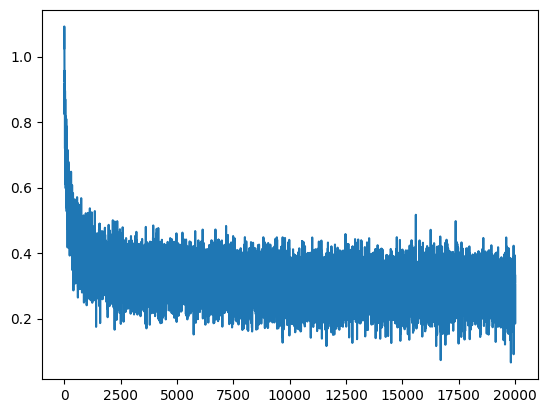

In [33]:
plt.plot(stepi, lossi)

In [13]:
# loss training set
emb = C[Xtr]
h = torch.tanh(emb.view(-1, 12) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
loss

tensor(1.9847, grad_fn=<NllLossBackward0>)

In [14]:
# loss validation set
emb = C[Xdev]
h = torch.tanh(emb.view(-1, 12) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1593, grad_fn=<NllLossBackward0>)

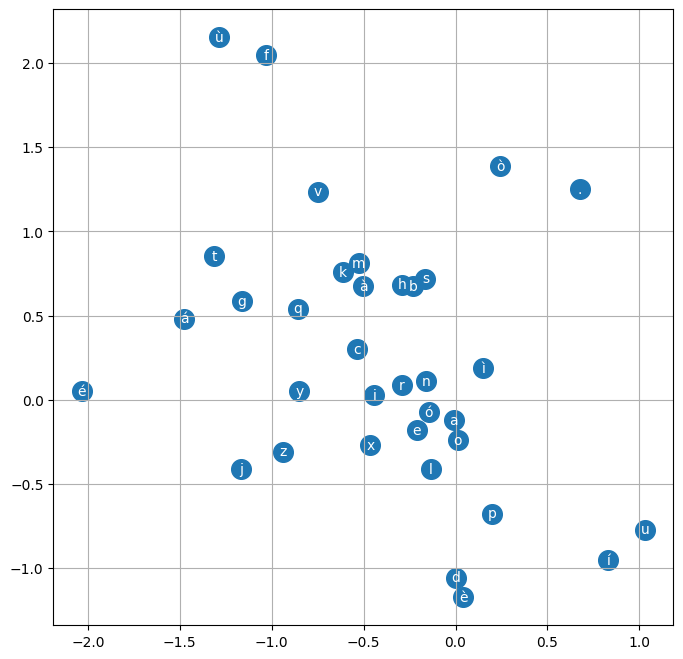

In [15]:
# visualise dimensions
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [16]:
# initialise context
context = [0] * block_size

torch.Size([1, 3, 4])

In [28]:
# generate 40 names
g = torch.Generator().manual_seed(2147483647 + 10)

for i in range(40):

    out = []
    context = [0] * block_size
    while True:
      emb = C[torch.tensor([context])]
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break

    print(''.join(itos[i] for i in out))

càrda.
anzu.
beni.
alca.
anzena.
berialolisalice.
bero.
ch.
boinu.
gianzina.
miu.
padu.
artoriu.
crikoeriacè.
lru.
doongithertori.
castzistina.
elbòìnzu.
igru.
paennica.
panmàrtergacogona.
papa.
gadmesgòèru.
baltoisu.
papqrerbu.
ziaminu.
linu.
dorici.
antedeudrarenmertinenpiulanu.
balia.
gitini.
papa.
anoiòezraanu.
càrtianu.
barfineldu.
jorrichemordu.
toretu.
bana.
andda.
cesmuu.


In [18]:
emb = C[Xte]
h = torch.tanh(emb.view(-1, 12) @ W1 + b1)
logits = h @ W2 + b2
loss_test = F.cross_entropy(logits, Yte)
print("Test loss:", loss_test.item())

Test loss: 2.1803436279296875


In [31]:
# bigram character-level model

#import dataset
import urllib.request

names_url = "https://raw.githubusercontent.com/alicecongiu01-oss/EXERCISE-3/refs/heads/main/Abele.txt"
names = urllib.request.urlopen(names_url).read()
names = names.decode("utf-8")
names = names.splitlines()

#preprocessing
import re
names = [w.strip() for w in names]
names = [w.lower() for w in names]
names = [''.join(c for c in w if c.isalpha()) for w in names]

import torch

#Initialise 35x35 tensor for bigram count
N = torch.zeros((35, 35), dtype = torch.int32)

#create stoi and itos dictionaries
chars = sorted(list(set("".join(names))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi["."] = 0
itos = {i:s for s,i in stoi.items()}

#training
for w in names:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    N[ix1, ix2] += 1

#probability normalisation and leplace smoothing
P = (N+1).float()
P /= P.sum(1, keepdims=True)

#generate 10 names with fixed seed
g = torch.Generator().manual_seed(2147483647)

for i in range(10):

  out = []
  ix = 0
  while True:
    p = P[ix]
    ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    out.append(itos[ix])
    if ix == 0:
      break
  print(''.join(out))

#evaluation: negative log likelihood
log_likelihood = 0.0
n = 0

for w in names:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    prob = P[ix1, ix2]
    logprob = torch.log(prob)
    log_likelihood += logprob
    n += 1


nll = -log_likelihood

print(f'{nll/n}')

cimba.
mmaclo.
aredddelùxzu.
mmìrinzu.
piseualisste.
a.
tu.
bànunia.
ameòre.
gituaéóèle.
2.2468907833099365
